## Sampling Techniques

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = {
    "Employee":["A","B","C","D","E","F","G","H","I","J"],
    "Salary":[50,60,70,80,90,100,110,120,130,140]
}
df = pd.DataFrame(data)
print("Population Data:")
print(df)

Population Data:
  Employee  Salary
0        A      50
1        B      60
2        C      70
3        D      80
4        E      90
5        F     100
6        G     110
7        H     120
8        I     130
9        J     140


In [5]:
#Population Mean
pop_mean = df["Salary"].mean()
print(pop_mean)

95.0


In [8]:
# Convenience Sampling

conv_sam = df.head(4)
print(conv_sam)
print("Sample Mean:",conv_sam["Salary"].mean())

  Employee  Salary
0        A      50
1        B      60
2        C      70
3        D      80
Sample Mean: 65.0


In [26]:
# Simple random sampling

simp_rand_sam = df.sample(n=4,random_state =1)
print(simp_rand_sam)

print(simp_rand_sam["Salary"].mean())

  Employee  Salary
2        C      70
9        J     140
6        G     110
4        E      90
102.5


In [30]:
#Systematic Sampling
n  = 4
N = 10
k = N/n
print(k)

#pick every 2nd employee starting from index 0 
systematic_sample = df.iloc[::2][:4]
print(systematic_sample)
print("Systematic_Sample:",systematic_sample["Salary"].mean())

2.5
  Employee  Salary
0        A      50
2        C      70
4        E      90
6        G     110
Systematic_Sample: 80.0


In [42]:
# Straitfied Sampling

low = df[df["Salary"]<80].sample(n =1 , random_state = 3)
print(low)
medium = df[(df["Salary"]>=80) & (df["Salary"]<=120 )].sample(n =2 , random_state = 2)
print(medium)
high = df[df["Salary"]>120].sample(n =1 , random_state = 3)
print(high)

strat_samp = pd.concat([low,medium,high])

print(strat_samp)

print("Sample mean:",strat_samp["Salary"].mean())

  Employee  Salary
1        B      60
  Employee  Salary
5        F     100
7        H     120
  Employee  Salary
9        J     140
  Employee  Salary
1        B      60
5        F     100
7        H     120
9        J     140
Sample mean: 105.0


In [52]:
# Culster Sampling

#define clusters
cluster1 = df.iloc[0:3]
cluster2 = df.iloc[3:7]
cluster3 = df.iloc[7:10]

clusters =  [cluster1,cluster2,cluster3]
np.random.seed(1)
selected_clusters = clusters[np.random.randint(0,len(clusters))]

print(selected_clusters)

print("Sample mean:",selected_cluster["Salary"].mean())

  Employee  Salary
3        D      80
4        E      90
5        F     100
6        G     110
Sample mean: 95.0


## Sampling Distribution

In [53]:
data = {
    "Employee":["A","B","C","D","E","F","G","H","I","J"],
    "Salary":[50,60,70,80,90,100,110,120,130,140]
}
df = pd.DataFrame(data)
print("Population Data:")
print(df)

Population Data:
  Employee  Salary
0        A      50
1        B      60
2        C      70
3        D      80
4        E      90
5        F     100
6        G     110
7        H     120
8        I     130
9        J     140


In [54]:
#Population Mean
pop_mean = df["Salary"].mean()
print(pop_mean)

95.0


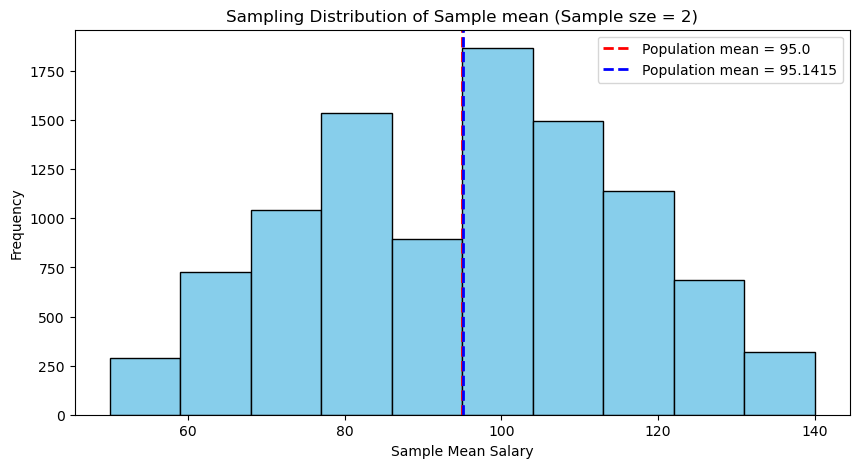

In [78]:
np.random.seed(1)

sample_size = 2
num_samples = 10000
sample_means = []

for i in range(num_samples):
    sample = df["Salary"].sample(n = sample_size,replace = True)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)
mean_sample_means  = sample_means.mean()
plt.figure(figsize = (10,5))
plt.hist(sample_means,bins = 10,color = "skyblue" ,edgecolor = 'black')
plt.axvline(pop_mean,
            color = 'r',
            linestyle = '--',
            linewidth = 2,
            label = f"Population mean = {pop_mean}")
plt.axvline(mean_sample_means,
            color = 'b',
            linestyle = '--',
            linewidth = 2,
            label = f"Population mean = {mean_sample_means}")
plt.title("Sampling Distribution of Sample mean (Sample sze = 2)")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()